In [ ]:
# Import libraries
import pandas as pd
from pathlib import Path
from ydata_profiling import ProfileReport

In [128]:
# Path
raw_file = Path(r"C:\Users\btigr\Documents\UAO\5\ETL\ETL_2026_1\lab_04\lab_04_dq-main\lab_04_dq-main/data/raw/retail_etl_dataset.csv")
print("Raw file:", raw_file)

# Read de csv
df_raw = pd.read_csv(raw_file)

Raw file: C:\Users\btigr\Documents\UAO\5\ETL\ETL_2026_1\lab_04\lab_04_dq-main\lab_04_dq-main\data\raw\retail_etl_dataset.csv


In [54]:
# Data first rows to inspect
df_raw.head(7)

,invoice_id,customer_id,product,quantity,price,total_revenue,country,invoice_date
0,22951,1102.0,Mouse,2,525.96,1051.92,Colombia,2023-03-25
1,21238,1435.0,Printer,6,74.92,449.52,colombia,2023-11-23
2,29165,1348.0,Monitor,1,576.56,576.56,colombia,2023-05-13
3,24727,1270.0,Mouse,3,353.25,1059.75,Ecuador,14-09-2023
4,23965,1106.0,Mouse,7,312.70,2188.90,Chile,2023-05-28
5,25686,1071.0,Phone,6,400.61,2403.66,Colombia,2023-11-20
6,29242,1188.0,Laptop,1,649.90,649.90,Colombia,2023-05-09


In [56]:
# Data shape or dimensions
print("Shape or df dimensions:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

Shape or df dimensions: (5100, 8)

Columns:
['invoice_id', 'customer_id', 'product', 'quantity', 'price', 'total_revenue', 'country', 'invoice_date']


In [ ]:
# Data types
print("Data types:", df_raw.dtypes)

Data types: invoice_id         int64
customer_id      float64
product           object
quantity           int64
price            float64
total_revenue    float64
country           object
invoice_date      object
dtype: object


In [105]:
# Missing values
print("Missing values:")
print(df_raw.isnull().sum())
print((df_raw.isnull().sum() / len(df_raw) * 100).round(2))

Missing values:
invoice_id         0
customer_id      202
product            0
quantity           0
price              0
total_revenue      0
country            0
invoice_date      13
dtype: int64
invoice_id       0.00
customer_id      3.96
product          0.00
quantity         0.00
price            0.00
total_revenue    0.00
country          0.00
invoice_date     0.25
dtype: float64


In [117]:
# Cardinality od categorical columns
# Check cardinality of categorical columns
print("\nCardinality of categorical columns:")
    
categorical_cols = ["product", "country", "invoice_date"]

for col in categorical_cols:
    if col in df_raw.columns:
        print(f"\n{col}:")
        print("Unique values:", df_raw[col].nunique())
        print("Top values:")
        print(df_raw[col].value_counts().head())


Cardinality of categorical columns:

product:
Unique values: 8
Top values:
product
Headphones    664
Keyboard      657
Mouse         654
Phone         645
Laptop        628
Name: count, dtype: int64

country:
Unique values: 7
Top values:
country
ecuador    767
Peru       740
CO         736
Ecuador    727
Chile      726
Name: count, dtype: int64

invoice_date:
Unique values: 471
Top values:
invoice_date
2023/05/15    98
2027-01-01    96
2023-02-26    25
2023-09-16    24
2023-06-29    23
Name: count, dtype: int64


In [ ]:
# Basic Statistics
print("Describe data:")
df_raw.describe()

Describe data:


,invoice_id,customer_id,quantity,price,total_revenue
count,5100.000000,4898.000000,5100.000000,5100.000000,5100.000000
mean,24964.647059,1251.237444,4.776471,496.229952,2332.439496
std,2887.931947,144.525463,2.825415,291.654276,2184.914094
min,20001.000000,1000.000000,-4.000000,-96.616618,-6719.280000
25%,22512.500000,1128.000000,3.000000,251.220000,692.310000
50%,24894.000000,1252.500000,5.000000,497.440000,1850.025000
75%,27435.500000,1378.000000,7.000000,742.112500,3611.070000
max,29993.000000,1499.000000,9.000000,999.510000,11294.130000


In [109]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
df_raw['invoice_id'].value_counts()

invoice_id
29549    6
24920    5
20615    5
28989    4
24524    4
        ..
28244    1
26846    1
22307    1
21228    1
28791    1
Name: count, Length: 3941, dtype: int64

In [101]:
# Value counts o duplicated data 
# Customer id
df_raw['customer_id'].value_counts()

customer_id
1038.0    20
1112.0    19
1475.0    19
1434.0    18
1172.0    18
          ..
1005.0     3
1087.0     3
1367.0     3
1090.0     3
1070.0     2
Name: count, Length: 500, dtype: int64

In [94]:
# Value counts o duplicated data 
# Countries
df_raw['country'].value_counts()

country
ecuador     767
Peru        740
CO          736
Ecuador     727
Chile       726
colombia    708
Colombia    696
Name: count, dtype: int64

In [95]:
# Value counts o duplicated data 
# Products
df_raw['product'].value_counts()

product
Headphones    664
Keyboard      657
Mouse         654
Phone         645
Laptop        628
Printer       623
Monitor       617
Tablet        612
Name: count, dtype: int64

In [111]:
import numpy as np
calc = df_raw["quantity"] * df_raw["price"]
invalid = np.abs(df_raw["total_revenue"] - calc) > 0.01

print("\n🧮 INVALID total_revenue:")
print(invalid.sum())


🧮 INVALID total_revenue:
148


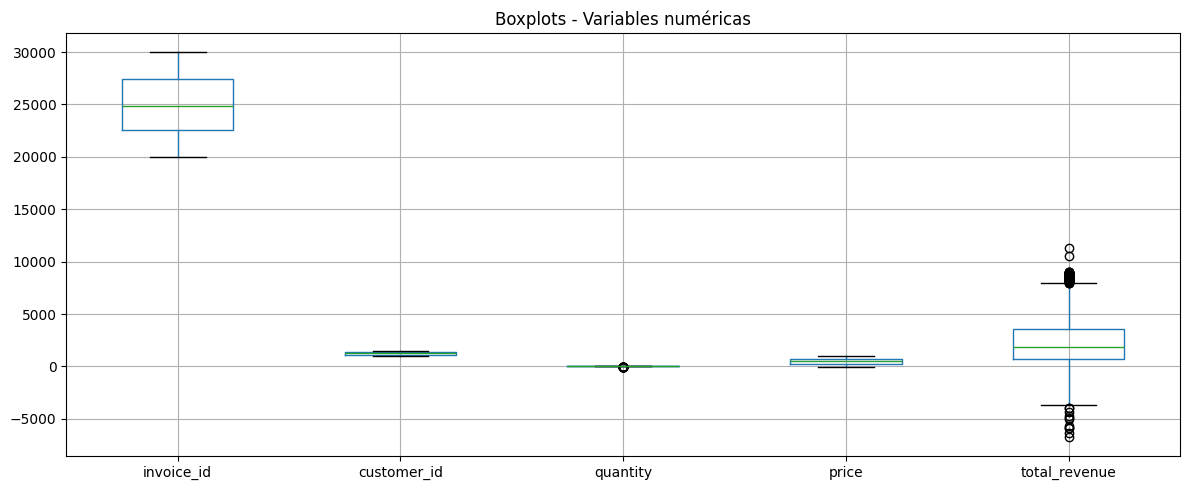

In [96]:
import matplotlib.pyplot as plt

numeric_cols = df_raw.select_dtypes(include='number').columns

df_raw[numeric_cols].boxplot(figsize=(12, 5), rot=0)
plt.title("Boxplots - Variables numéricas")
plt.tight_layout()
plt.show()

In [115]:
# ===============================
    # 📅 DATE FORMAT
    # ===============================
def detect_format(x):
    if pd.isnull(x):
            return "null"
    x = str(x)

    if "-" in x and len(x.split("-")[0]) == 4:
            return "YYYY-MM-DD"
    elif "/" in x and len(x.split("/")[0]) == 4:
            return "YYYY/MM/DD"
    elif "-" in x and len(x.split("-")[0]) == 2:
            return "DD-MM-YYYY"
    else:
            return "other"

formats = df_raw["invoice_date"].apply(detect_format)
print("\n📅 DATE FORMAT DISTRIBUTION:")
print(formats.value_counts())


📅 DATE FORMAT DISTRIBUTION:
invoice_date
YYYY-MM-DD    4909
YYYY/MM/DD      98
DD-MM-YYYY      78
null            13
other            2
Name: count, dtype: int64


In [132]:
# ===============================
# ⏳ FUTURE + NULL-LIKE
# ===============================
parsed = pd.to_datetime(df_raw["invoice_date"], errors="coerce")

print("\nFUTURE DATES:")
parsed_dates = pd.to_datetime(df_raw["invoice_date"], errors="coerce")
future_dates = parsed_dates > pd.Timestamp("2023-12-31")

print(future_dates.sum())

print("\nNULL-LIKE DATES:")
print(parsed.isnull().sum())



FUTURE DATES:
126

NULL-LIKE DATES:
191


In [97]:
# Generate the profile report
profile = ProfileReport(df_raw, title="My Data Profile")

# Or save the report to an HTML file
# Ruta específica donde quieres guardarlo
profile.to_file(r"C:\Users\btigr\Documents\UAO\5\ETL\ETL_2026_1\lab_04\lab_04_dq-main\lab_04_dq-main\reports\report_lab04.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 140.48it/s]


In [165]:
import great_expectations as gx

# Get the Ephemeral Data Context
context = gx.get_context()
assert type(context).__name__ == "EphemeralDataContext"

In [166]:
# Add a Pandas Data Source
data_source_name = "retail_etl_dataset"
data_source = context.data_sources.add_pandas(name=data_source_name)

# Add a Data Asset to the Data Source
data_asset_name = "retail_etl_dataset_asset"
data_asset = data_source.add_dataframe_asset(name=data_asset_name)

In [167]:
# Define the Batch Definition name
batch_definition_name = "retail_etl_dataset_batch"
# Add the Batch Definition
batch_definition = data_asset.add_batch_definition_whole_dataframe(batch_definition_name)
assert batch_definition.name == batch_definition_name

In [168]:
dataframe = pd.read_csv(raw_file)

batch_parameters = {"dataframe": dataframe}
# Retrieve the Batch
batch = batch_definition.get_batch(batch_parameters=batch_parameters)

In [169]:
# Create an Expectation Suite
expectation_suite_name = "retail_etl_dataset_suite"
suite = gx.ExpectationSuite(name=expectation_suite_name)

# Add Expectations

# Completness
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="customer_id")
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToNotBeNull(column="invoice_date")
)


# Uniqueness
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeUnique(column="invoice_id")
)


# Validity
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(column="quantity", min_value=1)
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(column="price", min_value=0.01)
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(column="product", value_set=["Headphones", "Keyboard", "Mouse", "Phone", "Laptop", "Printer", "Monitor", "Tablet"])
)


# Accuracy
df_raw["revenue_match"] = (
    abs(df_raw["total_revenue"] - df_raw["quantity"] * df_raw["price"]) <= 0.01
)

suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(
        column="revenue_match",
        value_set=[True]
    )
)


# Consistency
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeInSet(column="country", value_set=["Colombia", "Chile", "Peru", "Ecuador"])
)


# Timeliness
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToMatchRegex(column="invoice_date",regex=r"^\d{4}-\d{2}-\d{2}$")
)
suite.add_expectation(
    gx.expectations.ExpectColumnValuesToBeBetween(column="invoice_date", min_value="2023-01-01", max_value="2023-12-31")
)


# Add the Expectation Suite to the Context
context.suites.add(suite)

{
  "name": "retail_etl_dataset_suite",
  "id": "57833d98-c707-43ba-b992-433a51ab9295",
  "expectations": [
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "customer_id"
      },
      "meta": {},
      "id": "6f56b069-a58f-4ffd-8fe7-935af3761c15",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_not_be_null",
      "kwargs": {
        "column": "invoice_date"
      },
      "meta": {},
      "id": "ed9a8cdb-8b0c-4311-bc54-490526c964cb",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_unique",
      "kwargs": {
        "column": "invoice_id"
      },
      "meta": {},
      "id": "ac0c2e9c-7bb7-4ffd-9c88-63c3ed1090b6",
      "severity": "critical"
    },
    {
      "type": "expect_column_values_to_be_between",
      "kwargs": {
        "column": "quantity",
        "min_value": 1.0
      },
      "meta": {},
      "id": "3c7bca98-e197-46c2-b45e-f7c078aad064",
      "sever

In [170]:
# Validate the Data Against the Suite
validation_results = batch.validate(suite)
# Evaluate the Results
print(validation_results)

Calculating Metrics:  82%|████████▏ | 56/68 [00:00<00:00, 1130.30it/s]

{
  "success": false,
  "results": [
    {
      "success": false,
      "expectation_config": {
        "type": "expect_column_values_to_be_between",
        "kwargs": {
          "column": "invoice_date",
          "min_value": "2023-01-01",
          "max_value": "2023-12-31",
          "batch_id": "retail_etl_dataset-retail_etl_dataset_asset"
        },
        "meta": {},
        "id": "01c53111-d64c-429b-8412-d3a99c3ddeab",
        "severity": "critical"
      },
      "result": {},
      "meta": {},
      "exception_info": {
        "MetricConfigurationID(metric_name='column_values.between.condition', metric_domain_kwargs_id='c2a3140d3ab4f6161fb23c9d752c3ecb', metric_value_kwargs_id='1e49360030fd3b426f7fa151eedcd823')": {
          "exception_traceback": "Traceback (most recent call last):\n  File \"c:\\Users\\btigr\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\great_expectations\\execution_engine\\execution_engine.py\", line 577, in _process_direct_and_bundl